In [1]:
!git clone https://github.com/venkatsaikondra/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification.git

Cloning into 'CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification'...
remote: Enumerating objects: 43665, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 43665 (delta 16), reused 28 (delta 10), pack-reused 43627 (from 3)
Receiving objects: 100% (43665/43665), 487.49 MiB | 24.11 MiB/s, done.
Resolving deltas: 100% (94/94), done.
Updating files: 100% (118996/118996), done.


In [2]:
!pip install transformers[tf]

In [5]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
from transformers import BeitImageProcessor, BeitForImageClassification

# 1. Setup Paths & Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_DIR = '/content/CNN_ViT_Hybrid_Vit_Research_Pneumonia_4_Classification/Train_Test_Split_Vit_Data'
train_data_dir = os.path.join(BASE_DIR, 'train')
val_data_dir = os.path.join(BASE_DIR, 'val')

# 2. Initialize BEiT Components
# Use the specific BEiT processor for image normalization
feature_extractor_beit = BeitImageProcessor.from_pretrained('microsoft/beit-base-patch16-224')
model_beit = BeitForImageClassification.from_pretrained(
    'microsoft/beit-base-patch16-224',
    num_labels=4,
    ignore_mismatched_sizes=True
)
model_beit.to(device)

# 3. Dataset Class
class PneumoniaDataset(Dataset):
    def __init__(self, data_dir, feature_extractor):
        self.data_dir = data_dir
        self.feature_extractor = feature_extractor
        self.image_paths = []
        self.labels = []
        # Filter for directories to identify classes
        self.classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
        self.class_to_idx = {name: i for i, name in enumerate(self.classes)}

        for class_name in self.classes:
            path = os.path.join(data_dir, class_name)
            for img in os.listdir(path):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(path, img))
                    self.labels.append(self.class_to_idx[class_name])

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        inputs = self.feature_extractor(images=image, return_tensors='pt')
        return inputs['pixel_values'].squeeze(0), torch.tensor(self.labels[idx])

# 4. Create DataLoaders (Defining the missing variables)
train_ds = PneumoniaDataset(train_data_dir, feature_extractor_beit)
val_ds = PneumoniaDataset(val_data_dir, feature_extractor_beit)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_ds, batch_size=32, shuffle=False)

# 5. Training Configuration
optimizer = AdamW(model_beit.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
epochs = 25

# 6. Training Loop
print(f"Starting BEiT Training on {device}...")
for epoch in range(epochs):
    model_beit.train()
    train_loss, correct, total = 0, 0, 0

    for batch in train_dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_beit(inputs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # Validation Phase
    model_beit.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for v_batch in val_dataloader:
            v_inputs, v_labels = v_batch
            v_inputs, v_labels = v_inputs.to(device), v_labels.to(device)
            v_outputs = model_beit(v_inputs).logits
            _, v_pred = v_outputs.max(1)
            val_total += v_labels.size(0)
            val_correct += v_pred.eq(v_labels).sum().item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_dataloader):.4f} | "
          f"Train Acc: {100.*correct/total:.2f}% | Val Acc: {100.*val_correct/val_total:.2f}%")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

BeitForImageClassification LOAD REPORT from: microsoft/beit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Starting BEiT Training on cuda...
Epoch 1/25 | Loss: 0.4366 | Train Acc: 81.54% | Val Acc: 85.76%
Epoch 2/25 | Loss: 0.2975 | Train Acc: 87.68% | Val Acc: 86.60%
Epoch 3/25 | Loss: 0.2025 | Train Acc: 91.66% | Val Acc: 88.91%
Epoch 4/25 | Loss: 0.1295 | Train Acc: 94.90% | Val Acc: 91.05%
Epoch 5/25 | Loss: 0.0697 | Train Acc: 97.37% | Val Acc: 90.77%
Epoch 6/25 | Loss: 0.0579 | Train Acc: 98.04% | Val Acc: 90.03%
Epoch 7/25 | Loss: 0.0383 | Train Acc: 98.68% | Val Acc: 90.91%
Epoch 8/25 | Loss: 0.0381 | Train Acc: 98.72% | Val Acc: 91.84%
Epoch 9/25 | Loss: 0.0361 | Train Acc: 98.72% | Val Acc: 90.40%
Epoch 10/25 | Loss: 0.0336 | Train Acc: 98.89% | Val Acc: 91.93%
Epoch 11/25 | Loss: 0.0257 | Train Acc: 99.09% | Val Acc: 91.47%
Epoch 12/25 | Loss: 0.0298 | Train Acc: 98.92% | Val Acc: 91.74%
Epoch 13/25 | Loss: 0.0316 | Train Acc: 98.95% | Val Acc: 91.93%
Epoch 14/25 | Loss: 0.0236 | Train Acc: 99.11% | Val Acc: 91.65%
Epoch 15/25 | Loss: 0.0195 | Train Acc: 99.39% | Val Acc: 88.03%


Generating predictions for BEiT metrics...

Classification Report for BEiT:

                     precision    recall  f1-score   support

           Covid-19       1.00      0.99      0.99       539
             Normal       0.99      0.92      0.96       539
Pneumonia-Bacterial       0.87      0.80      0.83       539
    Pneumonia-Viral       0.78      0.91      0.84       539

           accuracy                           0.90      2156
          macro avg       0.91      0.90      0.90      2156
       weighted avg       0.91      0.90      0.90      2156



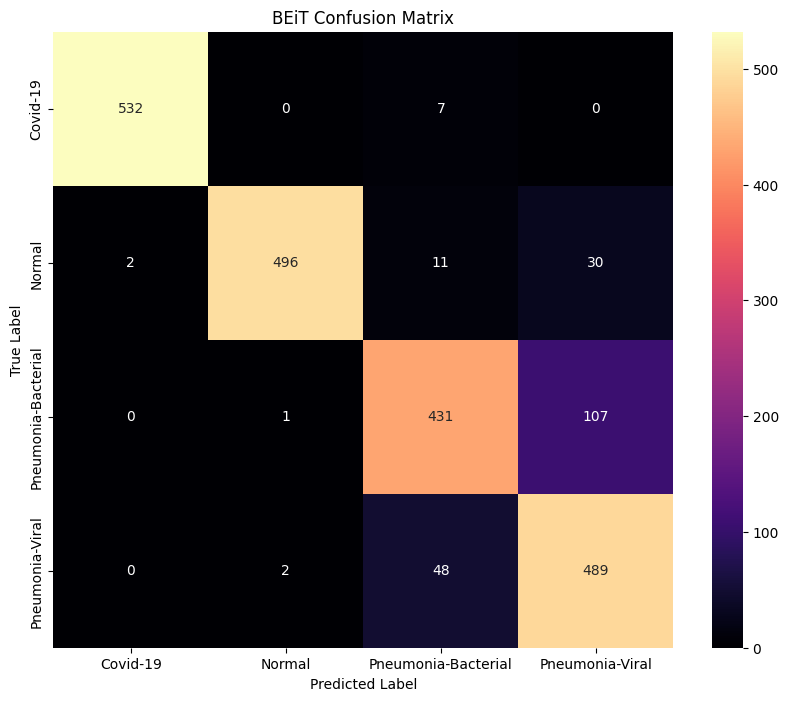

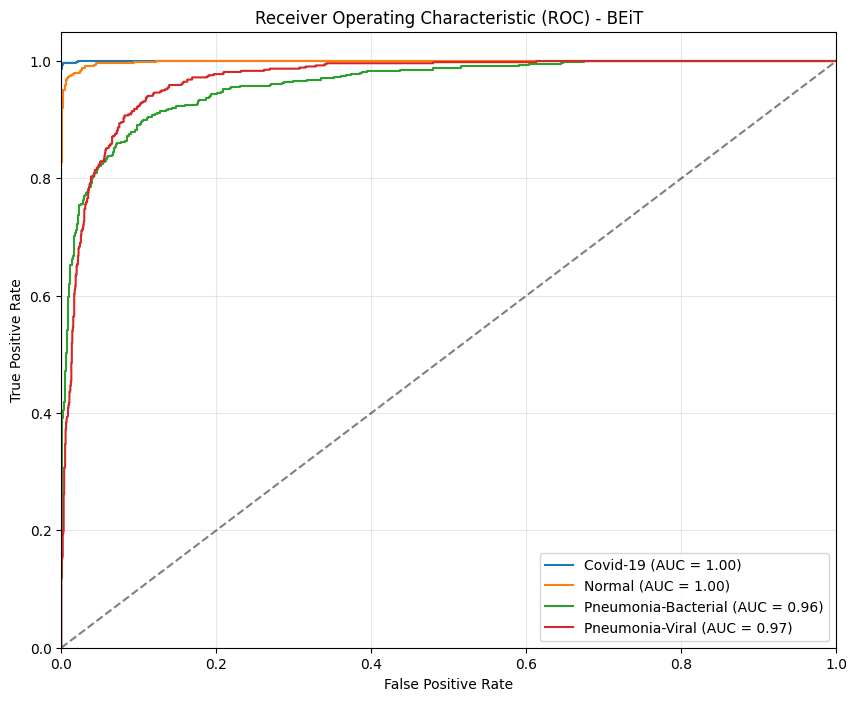

In [6]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from torch.utils.data import DataLoader

# Ensure model is in evaluation mode
model_beit.eval()

all_preds = []
all_labels = []
all_probs = []

print("Generating predictions for BEiT metrics...")

with torch.no_grad():
    for batch in val_dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model_beit(inputs).logits
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays for sklearn
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

class_names = ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']

# --- Metric A: Classification Report ---
print("\nClassification Report for BEiT:\n")
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

# --- Metric B: Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('BEiT Confusion Matrix')
plt.show()

# --- Metric C: Multi-class ROC Curve ---
plt.figure(figsize=(10, 8))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(all_labels == i, all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - BEiT')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [2]:
import json

file = "BEiT_Trained.ipynb"

with open(file, "r", encoding="utf-8") as f:
    nb = json.load(f)

# 🔥 Remove notebook-level widgets
nb.get("metadata", {}).pop("widgets", None)

# 🔥 Remove colab referenced widgets (just in case)
for cell in nb.get("cells", []):
    if "metadata" in cell and "colab" in cell["metadata"]:
        cell["metadata"]["colab"].pop("referenced_widgets", None)

with open(file, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("✅ Fully cleaned notebook (widgets removed)")

✅ Fully cleaned notebook (widgets removed)
